# Firing-rate PSTHs by brain region and LDA-1 bin, and single-neuron firing rate vs LDA-1
Mirror of `ff_psth_ldabin.ipynb`, but for **firing rate** instead of Fano factor. Two things happen:
1. A descriptive firing-rate PSTH per session x region (mean rate across neurons), averaged across
   sessions within each LDA-1 bin. Plotted three ways with the same helper: raw, baseline-subtracted
   (baseline -0.2..0 s), and raw with the pre/post windows shaded.
2. A single-neuron firing-rate metric in fixed pre-/post-stimulus windows -- **FR_pre** (baseline
   rate), **FR_post** (stimulus rate), and **FR_evoked = FR_post - FR_pre** -- tested for a
   relationship with `lda_1` using the *same* machinery as the FF notebook: a GLM
   `metric ~ lda_1 + C(region) + n_trials`, a session-stratified permutation test, and a JZS
   partial-correlation Bayes factor.

Reads the same per-trial firing-rate files as the FF notebook (`t_*` columns are already in Hz),
and the same LDA / trial-meta / region settings, so FF and FR results are directly comparable.

Notes on what is / isn't carried over from the FF notebook:
- **No mean-matching / condition residualization** of the PSTH: for firing rate the mean *is* the
  signal, so we do not subtract per-condition means (that would erase it). FF residualizes because
  it needs the variance around the condition mean.
- **No quench-onset metric** (that is FF-specific).
- Trial selection is parameterized (`CORRECT_ONLY`, `STRATIFY_BY_CONDITION`, `N_TARGET`).
  The session-permutation null handles neuron-within-session pseudoreplication; the `n_trials`
  covariate absorbs per-session trial-count differences; and `STRATIFY_BY_CONDITION` controls
  stimulus-composition differences across sessions.

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, hashlib
from scipy.stats import pearsonr
from iblatlas.regions import BrainRegions
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pingouin as pg
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid'); plt.rcParams['figure.facecolor'] = 'white'

In [63]:
prefix = '/home/ines/repositories/representation_learning_variability/paper-individuality/'
# prefix = '/Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/'
firing_rates_dir = prefix + 'data/firing_rates/'
clustering_dir = prefix + 'clustering/'

REGION_LEVEL = 'cosmos'    # 'cosmos' | 'beryl'
DROP = ['root', 'void']
MIN_NEURONS = 15           # per region in a session (descriptive curve)
N_BINS = 5                 # LDA-1 bins
SEED = 0

# --- trial selection (parameters) ---
CORRECT_ONLY = False           # keep only correct trials
STRATIFY_BY_CONDITION = True  # subsample ~equal trials per side x contrast condition (controls stimulus composition)
N_TARGET = None                # trials/session cap when subsampling (None = use all available)

# --- single-neuron firing-rate metric (fixed pre-/post-stimulus windows) ---
PRE_WINDOW = (-0.2, 0.0)   # baseline window (s)
POST_WINDOW = (0.1, 0.3)   # post-stimulus window (s)
MIN_TRIALS = 40            # min trials per session-region to trust a window FR estimate
MIN_FR_HZ = 0.1            # drop neurons whose pre OR post mean rate is below this (keeps log well-behaved)
N_PERM = 2000              # permutation iterations (matches the paper's neural-metric count)

lda = pd.read_pickle(clustering_dir + 'mouse_LDA_5_bins_cut06-07-2026').rename(columns={0: 'lda_1'})
lda['bin'] = lda['binned1'].cat.codes
bin_map = dict(zip(lda['session'], lda['bin']))
lda1_map = dict(zip(lda['session'], lda['lda_1']))
trials_df = pd.read_parquet(prefix + '4_mice/session_trial_meta_06-07-2026')
correct_by_session = trials_df[trials_df['feedback'] == 'correct'].groupby('session')['trial_id'].apply(set).to_dict()
br = BrainRegions()
print(f"LDA sessions: {lda['session'].nunique()}, bins: {sorted(lda['bin'].unique())}")

LDA sessions: 248, bins: [np.int8(0), np.int8(1), np.int8(2), np.int8(3), np.int8(4)]


## Compute firing rate per session x region: descriptive PSTH curve + single-neuron pre/post windows

In [64]:
pkl_files = sorted([f for f in os.listdir(firing_rates_dir) if f.startswith('firing_rate_')])
with open(os.path.join(firing_rates_dir, pkl_files[0]), 'rb') as f:
    s0 = pickle.load(f)
tcols = sorted([c for c in s0.columns if c.startswith('t_')], key=lambda x: float(x.split('_')[1]))
tsec = np.array([float(c.split('_')[1]) for c in tcols]); T = len(tcols)
binwidth = float(np.median(np.diff(tsec)))
pre_mask = (tsec >= PRE_WINDOW[0]) & (tsec < PRE_WINDOW[1])
post_mask = (tsec >= POST_WINDOW[0]) & (tsec < POST_WINDOW[1])
print(f"{T} time bins, {tsec.min():.2f}..{tsec.max():.2f}s, binwidth {binwidth*1000:.1f} ms; "
      f"pre {pre_mask.sum()} bins, post {post_mask.sum()} bins")

def session_seed(session):
    """Stable per-session seed so subsampled trial choice is reproducible."""
    h = int(hashlib.md5(str(session).encode()).hexdigest()[:8], 16)
    return (h + SEED) % (2**32)

def subsample_valid(valid_idx, conds, session):
    """Optionally subsample the valid-trial positions -- either capped at N_TARGET, or capped and
    balanced across side x contrast conditions. Returns positions into the trial axis (sorted)."""
    if not STRATIFY_BY_CONDITION and N_TARGET is None:
        return valid_idx
    rng_local = np.random.default_rng(session_seed(session))
    if STRATIFY_BY_CONDITION:
        cvals = conds[valid_idx]
        uniq = [c for c in pd.unique(cvals) if c is not None and not (isinstance(c, float) and np.isnan(c))]
        per = max(1, N_TARGET // max(1, len(uniq))) if N_TARGET else None
        picks = []
        for c in uniq:
            pos = valid_idx[cvals == c]
            if per is not None and len(pos) > per:
                pos = rng_local.choice(pos, per, replace=False)
            picks.append(pos)
        return np.sort(np.concatenate(picks)) if picks else valid_idx
    if N_TARGET and len(valid_idx) > N_TARGET:
        return np.sort(rng_local.choice(valid_idx, N_TARGET, replace=False))
    return valid_idx

records = []
neuron_records = []
for i, fn in enumerate(pkl_files):
    try:
        with open(os.path.join(firing_rates_dir, fn), 'rb') as f:
            d = pickle.load(f)
        d = d[~d['area'].isin(DROP)]
        if len(d) == 0: continue
        session = d['session'].iloc[0]
        if session not in bin_map: continue
        d = d.copy(); d['nuid'] = d['pid'].astype(str) + '__' + d['neuron_id'].astype(str)
        neurons = sorted(d['nuid'].unique()); nidx = {n: k for k, n in enumerate(neurons)}
        trials = sorted(d['trial_id'].unique()); tix = {t: k for k, t in enumerate(trials)}
        # A: neurons x trials x T, in Hz (t_* columns are already firing rates)
        A = np.full((len(neurons), len(trials), T), np.nan)
        A[d['nuid'].map(nidx).values, d['trial_id'].map(tix).values, :] = d[tcols].values

        na = d.groupby('nuid')['area'].first().reindex(neurons)
        if REGION_LEVEL == 'cosmos':
            cmap = dict(zip(na.dropna().unique(), br.acronym2acronym(na.dropna().unique(), mapping='Cosmos')))
            na = na.map(cmap)
        neu_area = na.values
        conds = d.drop_duplicates('trial_id').set_index('trial_id')['condition'].reindex(trials).values
        corr_set = correct_by_session.get(session, set())
        correct_mask = np.array([t in corr_set for t in trials]) if CORRECT_ONLY else np.ones(len(trials), dtype=bool)
        valid_idx = np.where(correct_mask)[0]
        valid_idx = subsample_valid(valid_idx, conds, session)

        for region in pd.unique(neu_area):
            if region is None or (isinstance(region, float) and np.isnan(region)): continue
            ni = np.where(neu_area == region)[0]
            if len(ni) < MIN_NEURONS: continue

            # --- descriptive PSTH curve: mean rate across trials, then across neurons ---
            per_neuron = np.nanmean(A[ni][:, valid_idx, :], axis=1)   # neurons x T
            curve = np.nanmean(per_neuron, axis=0)                    # T
            records.append(dict(session=session, region=region, bin=bin_map[session],
                                n_neurons=len(ni), n_trials=len(valid_idx), curve=curve))

            # --- single-neuron pre-/post-stimulus window firing rate ---
            if len(valid_idx) >= MIN_TRIALS:
                fr_pre = np.nanmean(np.nanmean(A[ni][:, valid_idx][:, :, pre_mask], axis=2), axis=1)
                fr_post = np.nanmean(np.nanmean(A[ni][:, valid_idx][:, :, post_mask], axis=2), axis=1)
                keep = (np.isfinite(fr_pre) & np.isfinite(fr_post)
                        & (fr_pre >= MIN_FR_HZ) & (fr_post >= MIN_FR_HZ))
                for nu, fp, po in zip(np.array(neurons)[ni][keep], fr_pre[keep], fr_post[keep]):
                    neuron_records.append(dict(session=session, region=region, nuid=nu,
                                               n_trials=len(valid_idx), fr_pre=fp, fr_post=po,
                                               fr_evoked=po - fp))
        if (i + 1) % 100 == 0: print(f"  {i+1}/{len(pkl_files)} files...")
    except Exception as e:
        print(f"Error {fn}: {e}")

curves = pd.DataFrame(records)
print(f"Descriptive curves: {len(curves)} session-region rows | {curves['session'].nunique()} sessions | "
      f"regions: {sorted(curves['region'].unique())}")

neuron_df = pd.DataFrame(neuron_records)
neuron_df['lda_1'] = neuron_df['session'].map(lda1_map)
neuron_df['bin'] = neuron_df['session'].map(bin_map)
neuron_df['log_fr_pre'] = np.log(neuron_df['fr_pre'].clip(lower=1e-6))
neuron_df['log_fr_post'] = np.log(neuron_df['fr_post'].clip(lower=1e-6))
print(f"Single-neuron FR table: {len(neuron_df)} neurons | {neuron_df['session'].nunique()} sessions | "
      f"regions: {neuron_df['region'].nunique()}")

90 time bins, -0.50..1.00s, binwidth 17.0 ms; pre 12 bins, post 12 bins
  100/380 files...
  200/380 files...
  300/380 files...
Descriptive curves: 574 session-region rows | 238 sessions | regions: ['CB', 'CNU', 'CTXsp', 'HB', 'HPF', 'HY', 'Isocortex', 'MB', 'OLF', 'TH']
Single-neuron FR table: 30051 neurons | 238 sessions | regions: 10


## Plot: firing-rate PSTH per region, colored by LDA-1 bin

In [65]:
def bins_by_session(df_sub):
    per_sess = (df_sub.groupby(['session', 'bin'])['curve']
                .apply(lambda cs: np.nanmean(np.vstack(cs.values), axis=0)).reset_index())
    return {b: np.vstack(g['curve'].values) for b, g in per_sess.groupby('bin')}

def plot_one(ax, df_sub, title, xlim=(-0.3, 0.6), baseline_subtract=False, shade=None,
             baseline_window=PRE_WINDOW, post_window=POST_WINDOW):
    """Firing-rate PSTH per LDA-1 bin.
    - baseline_subtract: if True, each session's own curve has its mean rate over baseline_window
      (-0.2..0 s) subtracted before averaging across sessions, so every trace sits at ~0 during
      baseline and the plot shows the stimulus-evoked *change* in rate.
    - shade: which analysis windows to mark with a light grey background band --
      None, 'baseline' (just the pre window), or 'prepost' (both pre and post windows).
      Defaults to 'baseline' when baseline_subtract is on."""
    if shade is None and baseline_subtract:
        shade = 'baseline'
    colors = plt.cm.coolwarm(np.linspace(0, 1, N_BINS))
    agg = bins_by_session(df_sub)
    base_mask = (tsec >= baseline_window[0]) & (tsec < baseline_window[1])
    if shade == 'baseline':
        ax.axvspan(baseline_window[0], baseline_window[1], color='0.85', alpha=0.6,
                   lw=0, zorder=0, label='baseline')
    elif shade == 'prepost':
        ax.axvspan(baseline_window[0], baseline_window[1], color='0.85', alpha=0.7,
                   lw=0, zorder=0, label='pre window')
        ax.axvspan(post_window[0], post_window[1], color='0.6', alpha=0.35,
                   lw=0, zorder=0, label='post window')
    xmask = (tsec >= xlim[0]) & (tsec <= xlim[1]); yv = []
    for b in range(N_BINS):
        if b not in agg: continue
        M = agg[b]
        if baseline_subtract:
            M = M - np.nanmean(M[:, base_mask], axis=1, keepdims=True)
        mean = np.nanmean(M, axis=0)
        ax.plot(tsec, mean, color=colors[b], lw=2, label=f'bin {b} (N={M.shape[0]})')
        if M.shape[0] > 1:
            sem = np.nanstd(M, axis=0) / np.sqrt(M.shape[0])
            ax.fill_between(tsec, mean - sem, mean + sem, color=colors[b], alpha=0.15)
            yv += [(mean - sem)[xmask], (mean + sem)[xmask]]
        else:
            yv += [mean[xmask]]
    ax.axvline(0, color='black', ls='--', alpha=0.5, lw=1.2)
    ax.set_xlabel('Time from stimulus onset(s)')
    ax.set_ylabel('baseline-subtracted firing rate (Hz)' if baseline_subtract else 'mean firing rate (Hz)')
    ax.set_title(title, fontsize=11)
    ax.set_xlim(list(xlim))
    if yv:
        allv = np.concatenate(yv); lo, hi = np.nanmin(allv), np.nanmax(allv)
        pad = 0.05 * (hi - lo) if hi > lo else 0.05 * abs(hi) + 1e-6
        ax.set_ylim(lo - pad, hi + pad)
        if baseline_subtract and lo - pad <= 0.0 <= hi + pad:
            ax.axhline(0.0, color='gray', ls=':', alpha=0.6)
    ax.legend(fontsize=8); sns.despine(ax=ax, offset=4)

def plot_regions(regions=None, baseline_subtract=False, shade=None):
    d = curves if regions is None else curves[curves['region'].isin(regions)]
    fig, ax = plt.subplots(figsize=(8, 6))
    plot_one(ax, d, f'Firing rate ({"all regions" if regions is None else regions})',
             baseline_subtract=baseline_subtract, shade=shade)
    plt.tight_layout(); plt.show()

def plot_grid(baseline_subtract=False, shade=None, suptitle=''):
    region_order = curves.groupby('region')['session'].nunique().sort_values(ascending=False).index.tolist()
    ncols = 4; nrows = int(np.ceil(len(region_order) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows), squeeze=False)
    for k, region in enumerate(region_order):
        plot_one(axes[k // ncols][k % ncols], curves[curves['region'] == region],
                 f'{region} ({curves[curves.region==region]["session"].nunique()} sessions)',
                 baseline_subtract=baseline_subtract, shade=shade)
    for k in range(len(region_order), nrows * ncols):
        axes[k // ncols][k % ncols].axis('off')
    fig.suptitle(suptitle, y=1.01, fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

### Raw firing-rate PSTH by region and LDA-1 bin

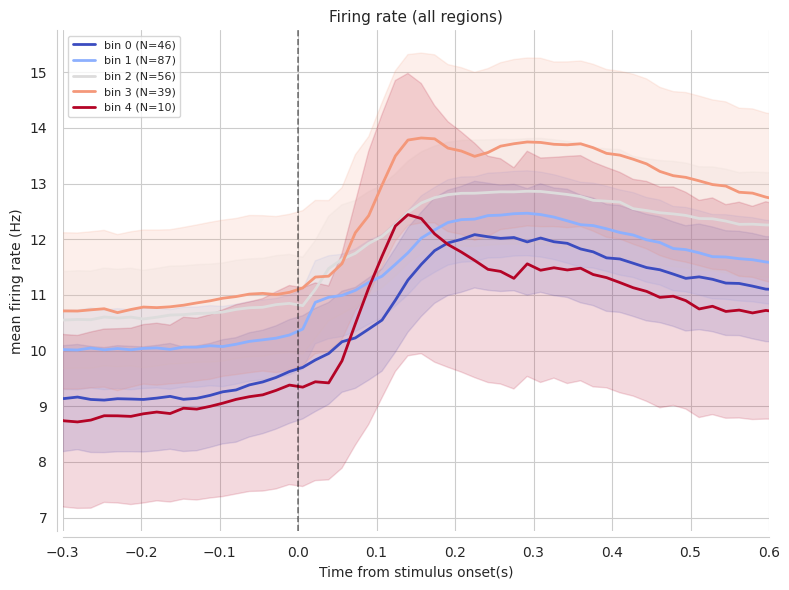

In [66]:
# plot_grid(suptitle='Firing-rate PSTH by region and LDA-1 bin')
plot_regions(regions=None)              # all regions pooled
# plot_regions(regions=['Isocortex'])     # a specific region (edit as needed)

### Baseline-subtracted firing-rate PSTH (baseline = -0.2..0 s)
Each session's trace has its mean rate over the -0.2..0 s baseline subtracted before averaging, so
every trace starts at ~0 and the panels show the stimulus-evoked *change* in rate. Baseline window
marked with a light grey band.

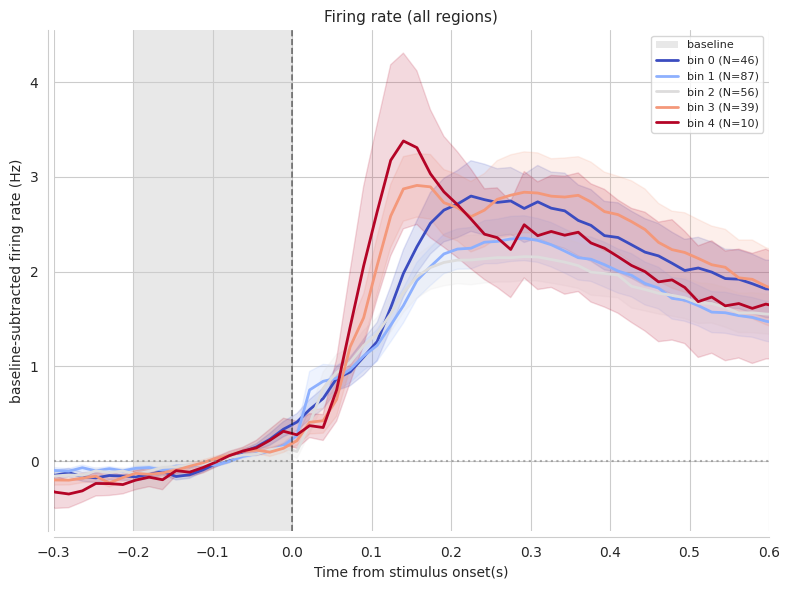

In [67]:
# plot_grid(baseline_subtract=True, suptitle='Baseline-subtracted firing-rate PSTH by region and LDA-1 bin')
plot_regions(regions=None, baseline_subtract=True)
# plot_regions(regions=['Isocortex'], baseline_subtract=True)

### Raw firing-rate PSTH with pre/post windows shaded
Raw rate with the pre-stimulus (-0.2..0 s) and post-stimulus (0..0.2 s) windows -- the two windows
used for the single-neuron FR metrics -- marked as light grey bands.

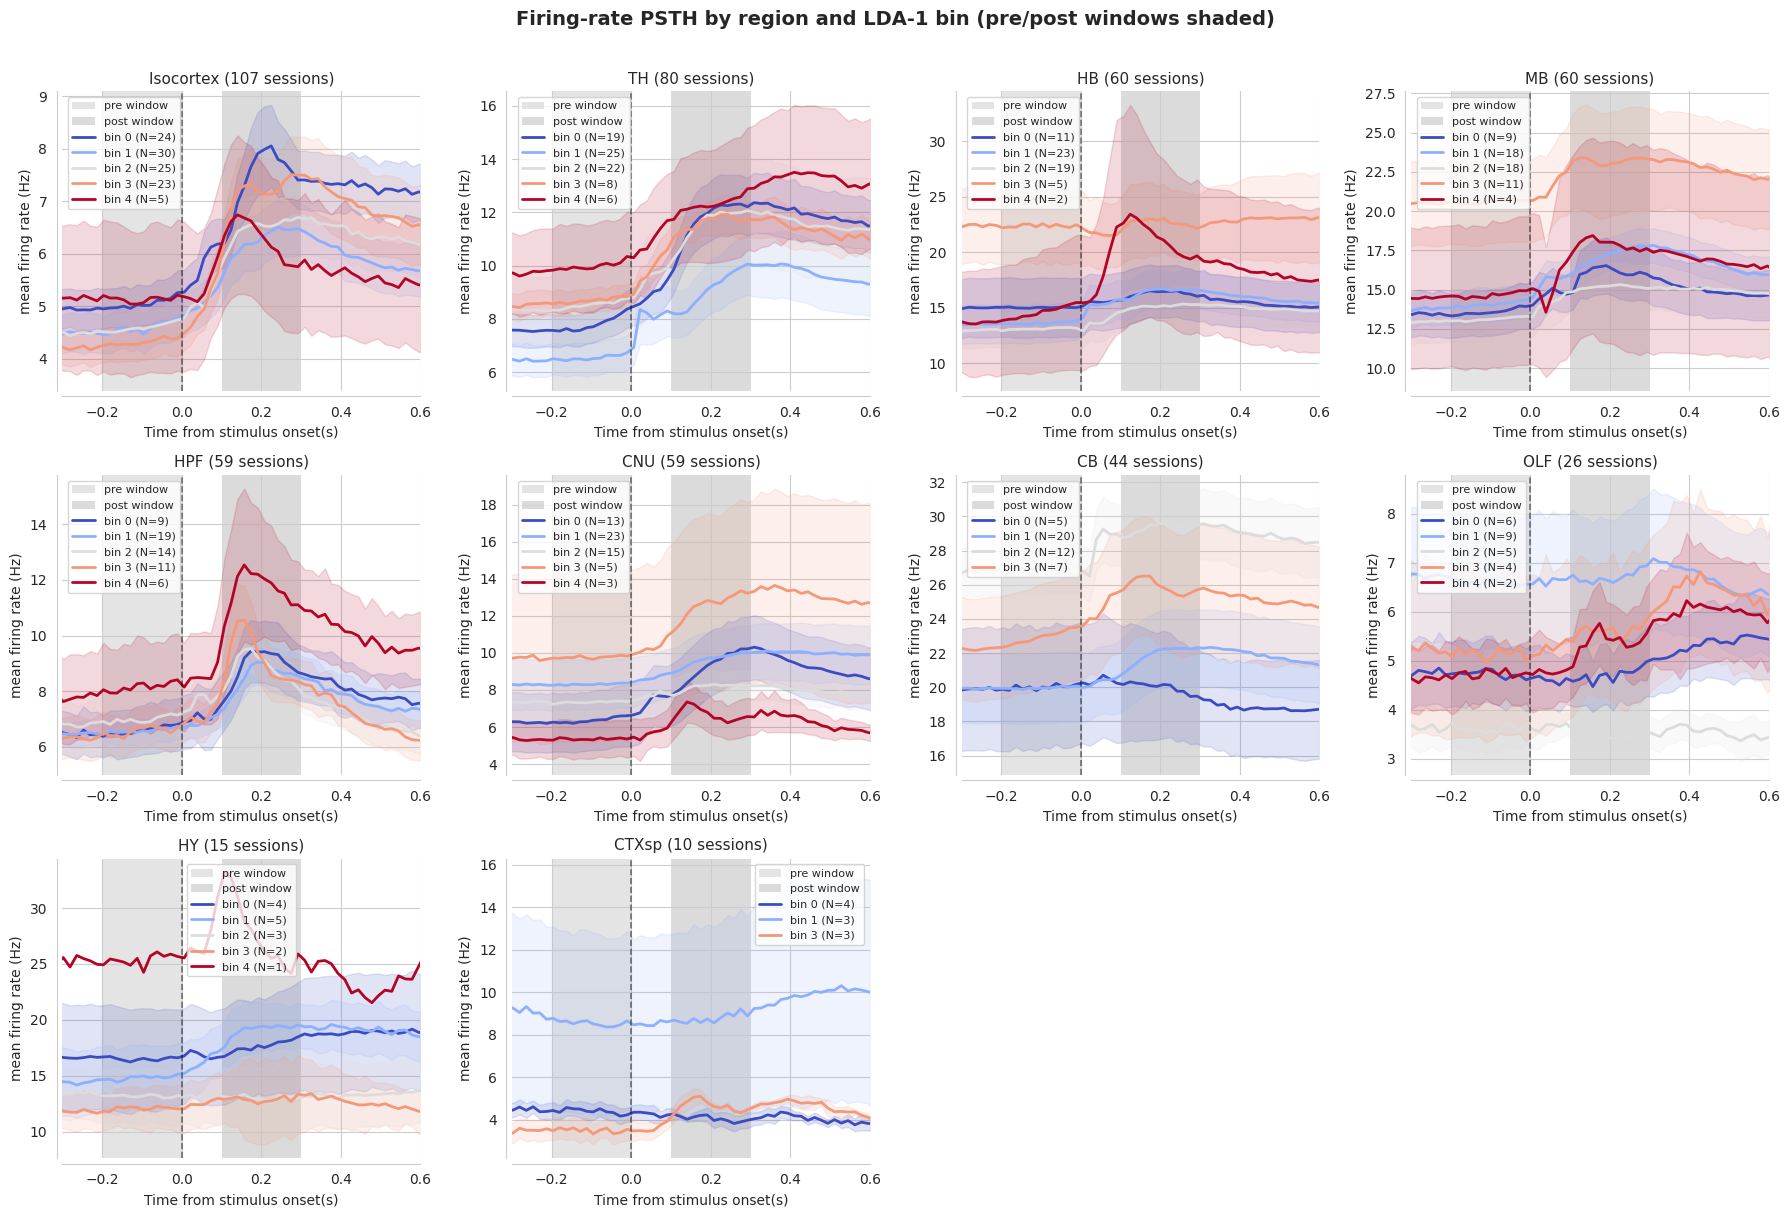

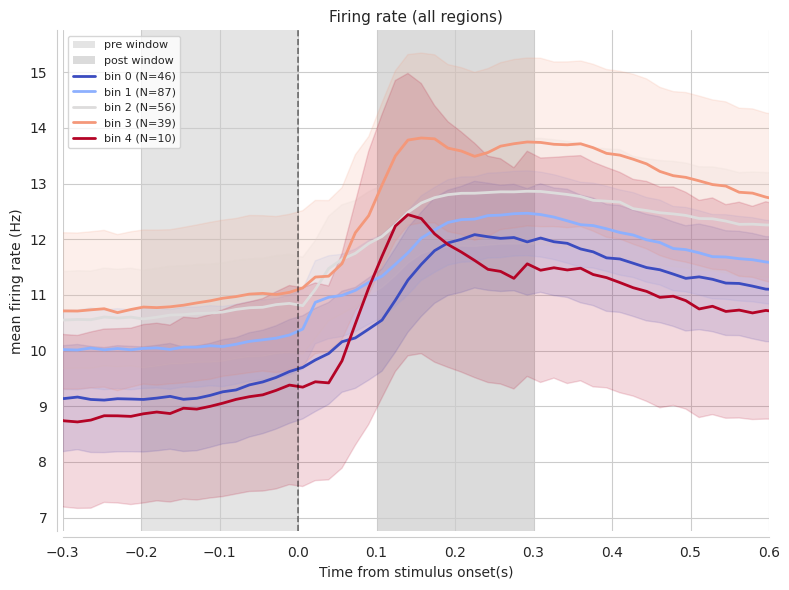

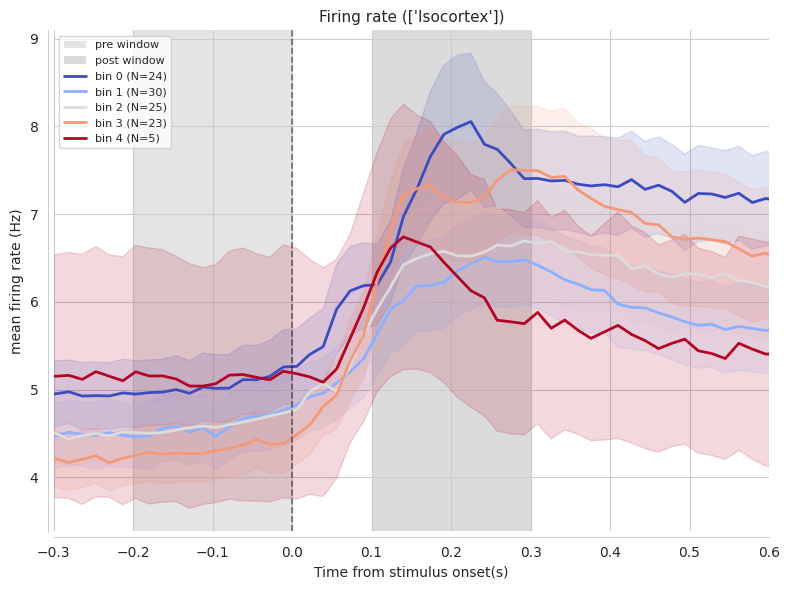

In [68]:
plot_grid(shade='prepost', suptitle='Firing-rate PSTH by region and LDA-1 bin (pre/post windows shaded)')
plot_regions(regions=None, shade='prepost')
plot_regions(regions=['Isocortex'], shade='prepost')

## Single-neuron firing rate vs LDA-1: GLM + session-permutation test + Bayes factor
Same test as the FF notebook, with `predictor = lda_1`:
`(log) FR_pre / (log) FR_post / FR_evoked ~ lda_1 + C(cluster_region) + n_trials`.
FR_pre and FR_post are strictly positive and right-skewed, so they are log-transformed; FR_evoked
is a signed difference so it stays on its natural scale (same rule the FF notebook applies to
FF_pre/FF_post vs FF_quench).

The GLM slope of `lda_1` is the test statistic. Its permutation null shuffles `lda_1` across
**sessions** (neurons within a session kept yoked), refitting the slope each iteration (n=2000).
The Bayes factor is the partial-correlation JZS BF (Wetzels & Wagenmakers, 2012) via
`pingouin.bayesfactor_pearson` after residualizing metric and `lda_1` on the other covariates
(Frisch-Waugh-Lovell) -- identical to the FF notebook.

In [69]:
def _design_matrix(df, region_col='region', extra_covars=('n_trials',)):
    """Intercept + region dummies (drop first) + extra numeric covariates, as a plain array."""
    dummies = pd.get_dummies(df[region_col], drop_first=True)
    Z = pd.concat([pd.Series(1.0, index=df.index, name='Intercept'), dummies,
                   df[list(extra_covars)].astype(float)], axis=1)
    return Z.values.astype(float)

def age_effect_test(df, y_col, predictor='lda_1', region_col='region', extra_covars=('n_trials',),
                     n_perm=N_PERM, seed=SEED, label=None):
    """GLM slope as test statistic, session-stratified permutation p-value, and a partial-
    correlation Bayes factor -- identical to ff_psth_ldabin.ipynb."""
    d = df.dropna(subset=[y_col, predictor, region_col] + list(extra_covars)).reset_index(drop=True)
    y = d[y_col].values.astype(float)
    x = d[predictor].values.astype(float)
    Z = _design_matrix(d, region_col, extra_covars)
    Zpinv = np.linalg.pinv(Z)

    y_resid = y - Z @ (Zpinv @ y)
    x_resid_obs = x - Z @ (Zpinv @ x)
    slope_obs = np.sum(x_resid_obs * y_resid) / np.sum(x_resid_obs ** 2)

    r_partial, _ = pearsonr(x_resid_obs, y_resid)
    n_eff = max(len(d) - (Z.shape[1] - 1), 3)
    bf10 = pg.bayesfactor_pearson(r_partial, n_eff)

    sess_to_x = d.groupby('session')[predictor].first()
    sess_index = d['session'].values
    rng = np.random.default_rng(seed)
    perm_slopes = np.empty(n_perm)
    for i in range(n_perm):
        shuffled = pd.Series(rng.permutation(sess_to_x.values), index=sess_to_x.index)
        x_perm = shuffled.reindex(sess_index).values.astype(float)
        x_perm_resid = x_perm - Z @ (Zpinv @ x_perm)
        perm_slopes[i] = np.sum(x_perm_resid * y_resid) / np.sum(x_perm_resid ** 2)
    p_perm = np.mean(np.abs(perm_slopes) >= np.abs(slope_obs))

    gdf = d.copy(); gdf['_y'] = y
    formula = f"_y ~ {predictor} + C({region_col}) + " + ' + '.join(extra_covars)
    glm_fit = smf.glm(formula, data=gdf, family=sm.families.Gaussian()).fit()

    return dict(label=label or y_col, n=len(d), n_sessions=d['session'].nunique(),
                slope=slope_obs, r_partial=r_partial, bf10=bf10, p_perm=p_perm,
                glm_slope=glm_fit.params[predictor], glm_p=glm_fit.pvalues[predictor])

def bf_label(bf):
    if bf > 10: return 'strong H1'
    if bf > 3: return 'moderate H1'
    if bf < 1 / 10: return 'strong H0'
    if bf < 1 / 3: return 'moderate H0'
    return 'inconclusive'

results = {
    'FR_pre (log)': age_effect_test(neuron_df, 'log_fr_pre',
                                    label='log FR_pre ~ lda_1 + C(region) + n_trials'),
    'FR_post (log)': age_effect_test(neuron_df, 'log_fr_post',
                                     label='log FR_post ~ lda_1 + C(region) + n_trials'),
    'FR_evoked': age_effect_test(neuron_df, 'fr_evoked',
                                 label='FR_evoked ~ lda_1 + C(region) + n_trials'),
}

print(f"{'metric':<16}{'n':>7}{'n_sess':>8}{'slope':>10}{'r_partial':>11}{'BF10':>10}{'evidence':>14}{'p_perm':>10}")
for name, r in results.items():
    print(f"{name:<16}{r['n']:>7}{r['n_sessions']:>8}{r['slope']:>10.4f}{r['r_partial']:>11.4f}"
          f"{r['bf10']:>10.3g}{bf_label(r['bf10']):>14}{r['p_perm']:>10.4f}")

metric                n  n_sess     slope  r_partial      BF10      evidence    p_perm
FR_pre (log)      30051     238    0.0081     0.0211      5.93   moderate H1    0.2700
FR_post (log)     30051     238   -0.0026    -0.0069    0.0148     strong H0    0.7055
FR_evoked         30051     238    0.0035     0.0013   0.00741     strong H0    0.9135


## Firing rate vs LDA-1 (session-averaged for display; test statistics from the single-neuron GLM above)
Points and color both encode `lda_1` (coolwarm). Regression lines are only drawn when `BF10 > 3`
(moderate-or-better evidence for H1), the same plotting convention the FF notebook uses.

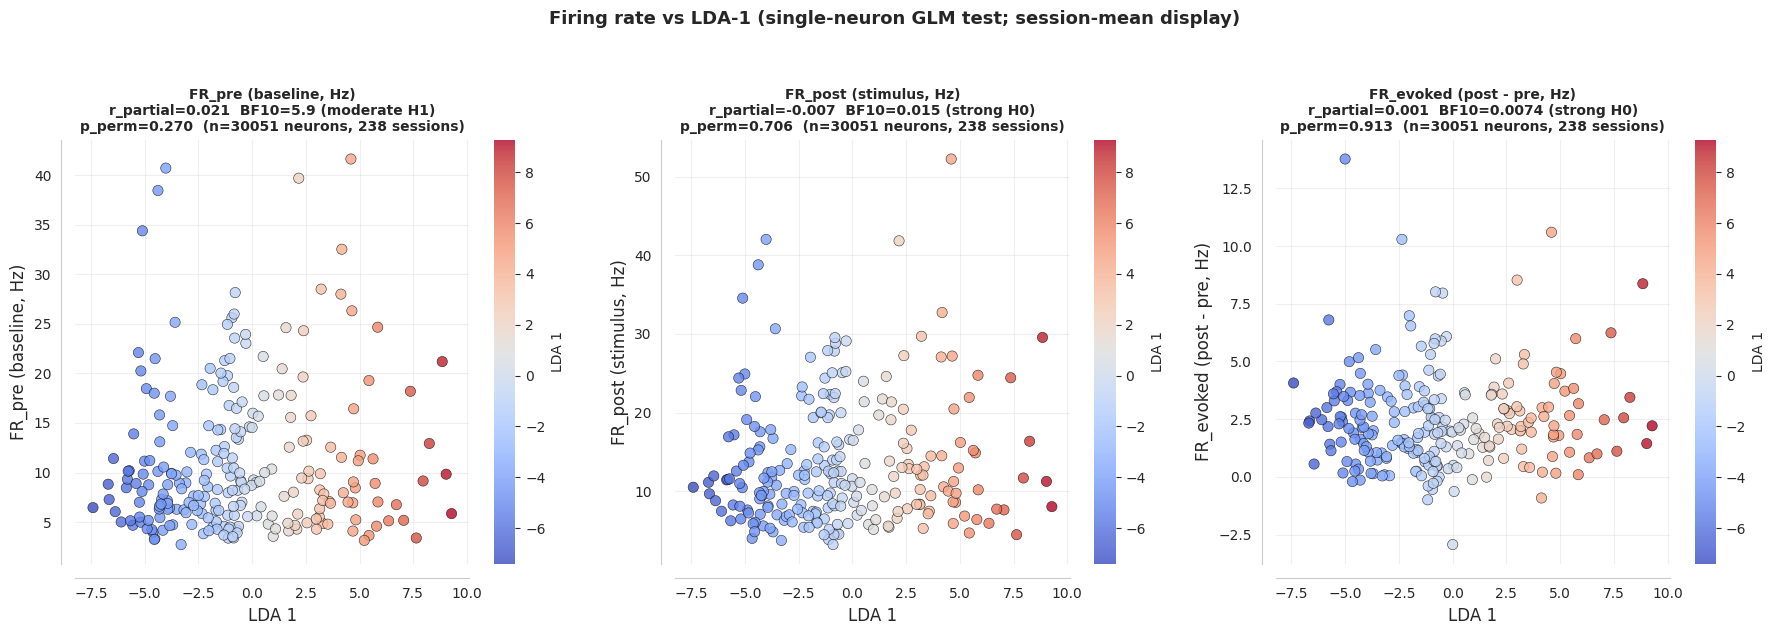

In [70]:
session_fr = neuron_df.groupby('session').agg(
    fr_pre=('fr_pre', 'mean'), fr_post=('fr_post', 'mean'), fr_evoked=('fr_evoked', 'mean'),
    lda_1=('lda_1', 'first')).reset_index()

panels = [('fr_pre', 'FR_pre (baseline, Hz)', results['FR_pre (log)']),
          ('fr_post', 'FR_post (stimulus, Hz)', results['FR_post (log)']),
          ('fr_evoked', 'FR_evoked (post - pre, Hz)', results['FR_evoked'])]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (col, title, res) in zip(axes, panels):
    d = session_fr.dropna(subset=[col, 'lda_1'])
    x = d['lda_1'].values; y = d[col].values
    sc = ax.scatter(x, y, c=x, cmap='coolwarm', alpha=0.8, s=55, edgecolors='black', linewidth=0.4)
    if res['p_perm'] < .05:
        z = np.polyfit(x, y, 1); xl = np.linspace(x.min(), x.max(), 100)
        ax.plot(xl, np.polyval(z, xl), 'k-', lw=2.5)
    cb = fig.colorbar(sc, ax=ax); cb.set_label('LDA 1'); cb.outline.set_visible(False)
    ax.set_xlabel('LDA 1', fontsize=12); ax.set_ylabel(title, fontsize=12)
    ax.set_title(f"{title}\nr_partial={res['r_partial']:.3f}  BF10={res['bf10']:.2g} ({bf_label(res['bf10'])})\n"
                 f"p_perm={res['p_perm']:.3f}  (n={res['n']} neurons, {res['n_sessions']} sessions)",
                 fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3); sns.despine(ax=ax, offset=10)
fig.suptitle('Firing rate vs LDA-1 (single-neuron GLM test; session-mean display)', y=1.05, fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()